# IPCC Component Sensitivity Extraction and Hindcast

Extract the temperature sensitivities implied by IPCC AR6 component projections
using the same model structures we use for observational calibration, then run
those sensitivities backward through observed temperature to hindcast the
observational record.

**Components:**
1. Thermosteric — single-layer ODE fit to IPCC ocean dynamics
2. Glaciers — linear/quadratic fit to IPCC glacier component
3. Greenland — SMB/D decomposition from ISMIP6 model output + ODE fit to dynamic component

**Data sources:**
- IPCC FACTS confidence-level NetCDFs (medium confidence, decadal)
- ISMIP6 Greenland model output (Goelzer et al. 2020, Zenodo DOI:10.5281/zenodo.3939037)
- Observational: Berkeley Earth GMST, NOAA thermosteric, GlaMBIE glaciers, Mouginot Greenland

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import netCDF4 as nc
import os
import warnings
from scipy.optimize import minimize
from scipy.interpolate import interp1d
warnings.filterwarnings('ignore', category=FutureWarning)

from slr_data_readers import (
    read_berkeley_earth, read_berkeley_earth_gridded,
    read_glambie_global,
)
from slr_forecast.readers.ice_sheets import read_mouginot2019_greenland
from bayesian_dols import build_level_design_vectors, solve_twolayer_ode
from component_projections import read_ipcc_component_nc

# Paths
H5_PATH   = '../data/processed/slr_processed_data.h5'
RAW_DIR   = '../data/raw'
FIG_DIR   = '../figures'
ISMIP6_DIR = f'{RAW_DIR}/ismip6_greenland/v7_CMIP5_pub'
CONF_BASE = f'{RAW_DIR}/ipcc_ar6/slr/ar6/global/confidence_output_files'

M_TO_MM = 1000.0
BASELINE_YEAR = 2005.0

# ── Load temperatures ──
df_temp = pd.read_hdf(H5_PATH, 'harmonized/df_berkeley_h')
temp_time_monthly = (df_temp.index.year + (df_temp.index.month - 0.5) / 12.0).values
temp_monthly = df_temp['temperature'].values

# Annual GMST
T_annual = pd.Series(temp_monthly, index=temp_time_monthly).groupby(
    np.floor(temp_time_monthly)).mean()
T_annual_years = T_annual.index.values.astype(float) + 0.5
T_annual_vals = T_annual.values

# ── Load IPCC SSP temperatures ──
ssp_keys = {
    'SSP1-2.6': 'SSP1_2_6', 'SSP2-4.5': 'SSP2_4_5',
    'SSP3-7.0': 'SSP3_7_0', 'SSP5-8.5': 'SSP5_8_5',
}
ipcc_temp = {}
with pd.HDFStore(H5_PATH, 'r') as store:
    temp_hist = store['/projections/temp/Historical']
    for name, key in ssp_keys.items():
        ipcc_temp[name] = store[f'/projections/temp/{key}']

# Rebaseline IPCC temps to 1995-2005
berk_annual = df_temp[['temperature']].resample('YS').mean()
berk_annual['decimal_year'] = [t.year + 0.5 for t in berk_annual.index]
offsets = []
for _, row in temp_hist.iterrows():
    yr = row['decimal_year']
    match = berk_annual[np.abs(berk_annual['decimal_year'] - yr) < 0.6]
    if len(match) > 0:
        offsets.append(row['temperature'] - match['temperature'].values[0])
TEMP_OFFSET = np.mean(offsets)

# SSP GMST trajectories (rebased)
ssp_gmst = {}
for name, df_ssp in ipcc_temp.items():
    hist_part = temp_hist[temp_hist['decimal_year'] < 2015].copy()
    combined = pd.concat([hist_part, df_ssp]).sort_index()
    combined = combined[~combined.index.duplicated(keep='last')]
    combined['temperature'] -= TEMP_OFFSET
    ssp_gmst[name] = combined

# ── Load observations for validation ──
# NOAA thermosteric
df_noaa = pd.read_hdf(H5_PATH, 'harmonized/df_noaa_tsl_0_700m')
noaa_year = df_noaa['decimal_year'].values
noaa_tsl = df_noaa['tsl_mm'].values / M_TO_MM  # mm → m
bl_noaa = np.argmin(np.abs(noaa_year - BASELINE_YEAR))
noaa_tsl_rebase = noaa_tsl - noaa_tsl[bl_noaa]

# GlaMBIE glaciers
df_glac = read_glambie_global(f'{RAW_DIR}/glaciers/0_global_glambie_consensus.csv')
glac_year = df_glac['decimal_year'].values
glac_cumul = np.cumsum(df_glac['mass_balance'].values)
bl_gl = np.argmin(np.abs(glac_year - BASELINE_YEAR))
glac_cumul -= glac_cumul[bl_gl]

# Mouginot Greenland
df_mou = read_mouginot2019_greenland(f'{RAW_DIR}/ice_sheets/greenland/mouginot2019_data.xlsx')
mou_year = df_mou['decimal_year'].values.astype(float)
mou_gris = df_mou['cumulative_mb'].values
bl_mou = np.argmin(np.abs(mou_year - BASELINE_YEAR))
mou_gris -= mou_gris[bl_mou]

print('Data loaded OK')
print(f'SSPs: {list(ssp_gmst.keys())}')
print(f'NOAA thermosteric: {noaa_year[0]:.0f}–{noaa_year[-1]:.0f}')
print(f'GlaMBIE: {glac_year[0]:.0f}–{glac_year[-1]:.0f}')
print(f'Mouginot: {mou_year[0]:.0f}–{mou_year[-1]:.0f}')

Data loaded OK
SSPs: ['SSP1-2.6', 'SSP2-4.5', 'SSP3-7.0', 'SSP5-8.5']
NOAA thermosteric: 1956–2026
GlaMBIE: 2000–2024
Mouginot: 1972–2018


## 1. IPCC Component Extraction

Load the IPCC FACTS medium-confidence component projections (decadal, 2020–2150)
for ocean dynamics, glaciers, and GIS.

In [2]:
# ── Load IPCC FACTS components ──
SSP_CODE_MAP = {
    'SSP1-2.6': 'ssp126', 'SSP2-4.5': 'ssp245',
    'SSP3-7.0': 'ssp370', 'SSP5-8.5': 'ssp585',
}

ipcc_components = {}  # {ssp: {component: {'years': ..., 'quantiles': ..., 'slc': ...}}}

for ssp, code in SSP_CODE_MAP.items():
    ipcc_components[ssp] = {}
    for comp in ['oceandynamics', 'glaciers', 'GIS']:
        data = read_ipcc_component_nc(CONF_BASE, 'medium_confidence', code, comp)
        if data is not None:
            # Extract median
            q50 = np.argmin(np.abs(data['quantiles'] - 0.5))
            q17 = np.argmin(np.abs(data['quantiles'] - 0.17))
            q83 = np.argmin(np.abs(data['quantiles'] - 0.83))
            ipcc_components[ssp][comp] = {
                'years': data['years'],
                'median_mm': data['slc'][q50].flatten(),
                'p17_mm': data['slc'][q17].flatten(),
                'p83_mm': data['slc'][q83].flatten(),
            }
            print(f'{ssp} {comp}: {data["years"][0]:.0f}–{data["years"][-1]:.0f}, '
                  f'median at 2100 = {data["slc"][q50].flatten()[-5]:.0f} mm')

SSP1-2.6 oceandynamics: 2020–2300, median at 2100 = 242 mm
SSP1-2.6 glaciers: 2020–2150, median at 2100 = 103 mm
SSP1-2.6 GIS: 2020–2150, median at 2100 = 87 mm
SSP2-4.5 oceandynamics: 2020–2300, median at 2100 = 472 mm
SSP2-4.5 glaciers: 2020–2150, median at 2100 = 135 mm
SSP2-4.5 GIS: 2020–2150, median at 2100 = 120 mm
SSP3-7.0 oceandynamics: 2020–2300, median at 2100 = 896 mm
SSP3-7.0 glaciers: 2020–2150, median at 2100 = 165 mm
SSP3-7.0 GIS: 2020–2150, median at 2100 = 144 mm
SSP5-8.5 oceandynamics: 2020–2300, median at 2100 = 1039 mm
SSP5-8.5 glaciers: 2020–2150, median at 2100 = 190 mm
SSP5-8.5 GIS: 2020–2150, median at 2100 = 166 mm


## 2. Thermosteric

Fit a single-layer ODE (same structure as our observational model) to the
IPCC ocean dynamics trajectory for each SSP.

Model: dS_u/dt = (T - S_u)/tau_u, eta = a*S_u^2 + b*S_u + c*t + H0

In [3]:
# ── Fit single-layer ODE to IPCC ocean dynamics ──
# For each SSP: build monthly T from the SSP pathway, fit [a, b, c, tau_u, H0]
# to the IPCC median trajectory via least squares.

def fit_ode_to_trajectory(years_target, slc_target_mm, T_monthly, t_monthly,
                          p0=None):
    """Fit single-layer ODE to a smooth trajectory (no noise).

    Parameters: theta = [a, b, c, log_tau_u, H0]
    Returns dict with fitted parameters and hindcast function.
    """
    slc_target_m = slc_target_mm / M_TO_MM

    def forward(theta):
        a, b, c, log_tau, H0 = theta
        tau = np.exp(log_tau)
        S_u, _ = solve_twolayer_ode(T_monthly, t_monthly, tau, np.inf)
        # Evaluate at target years
        S_u_at_yr = np.interp(years_target, t_monthly, S_u)
        t_rel = years_target - years_target[0]
        H = a * S_u_at_yr**2 + b * S_u_at_yr + c * t_rel + H0
        return H

    def cost(theta):
        H = forward(theta)
        return np.sum((H - slc_target_m)**2)

    if p0 is None:
        p0 = [0.01, 0.05, 0.0003, np.log(10.0), 0.0]

    res = minimize(cost, p0, method='Nelder-Mead',
                   options={'maxiter': 50000, 'xatol': 1e-10, 'fatol': 1e-15})

    theta_opt = res.x
    H_fit = forward(theta_opt)
    ss_res = np.sum((H_fit - slc_target_m)**2)
    ss_tot = np.sum((slc_target_m - np.mean(slc_target_m))**2)
    r2 = 1 - ss_res / ss_tot

    return {
        'a': theta_opt[0], 'b': theta_opt[1], 'c': theta_opt[2],
        'tau_u': np.exp(theta_opt[3]), 'H0': theta_opt[4],
        'r2': r2, 'H_fit_m': H_fit, 'theta': theta_opt,
        'forward': forward,
    }

# Fit for each SSP
thermo_fits = {}

for ssp in SSP_CODE_MAP:
    if 'oceandynamics' not in ipcc_components[ssp]:
        continue

    comp = ipcc_components[ssp]['oceandynamics']
    years_ipcc = comp['years']
    slc_ipcc = comp['median_mm']

    # Build monthly T for this SSP
    df_ssp = ssp_gmst[ssp]
    ssp_years = df_ssp['decimal_year'].values
    ssp_T = df_ssp['temperature'].values
    # Splice historical + SSP monthly
    ssp_start = ssp_years[0]
    hist_mask = temp_time_monthly < ssp_start
    ssp_monthly_t = np.arange(ssp_start, ssp_years[-1] + 0.5/12, 1/12)
    ssp_monthly_T = np.interp(ssp_monthly_t, ssp_years, ssp_T)
    t_full = np.concatenate([temp_time_monthly[hist_mask], ssp_monthly_t])
    T_full = np.concatenate([temp_monthly[hist_mask], ssp_monthly_T])

    fit = fit_ode_to_trajectory(years_ipcc, slc_ipcc, T_full, t_full)
    thermo_fits[ssp] = fit

    print(f'{ssp}: a={fit["a"]*M_TO_MM:.3f} mm/°C², b={fit["b"]*M_TO_MM:.3f} mm/°C, '
          f'c={fit["c"]*M_TO_MM:.3f} mm/yr, τ_u={fit["tau_u"]:.1f} yr, R²={fit["r2"]:.6f}')

# Cross-SSP comparison
print(f'\nCross-SSP sensitivity spread:')
bs = [thermo_fits[s]['b']*M_TO_MM for s in thermo_fits]
taus = [thermo_fits[s]['tau_u'] for s in thermo_fits]
print(f'  b: {np.mean(bs):.3f} ± {np.std(bs):.3f} mm/°C')
print(f'  τ_u: {np.mean(taus):.1f} ± {np.std(taus):.1f} yr')

SSP1-2.6: a=-350.677 mm/°C², b=-72.833 mm/°C, c=0.564 mm/yr, τ_u=1503.8 yr, R²=0.995623
SSP2-4.5: a=47.992 mm/°C², b=-76.756 mm/°C, c=1.608 mm/yr, τ_u=0.0 yr, R²=0.995056
SSP3-7.0: a=21.448 mm/°C², b=-102.338 mm/°C, c=3.911 mm/yr, τ_u=0.0 yr, R²=0.998423
SSP5-8.5: a=18.348 mm/°C², b=-97.634 mm/°C, c=4.463 mm/yr, τ_u=0.0 yr, R²=0.997810

Cross-SSP sensitivity spread:
  b: -87.390 ± 12.781 mm/°C
  τ_u: 375.9 ± 651.2 yr


SSP1-2.6 hindcast: R²=-0.8285, RMSE=14.8 mm
SSP2-4.5 hindcast: R²=-1.5155, RMSE=17.4 mm
SSP3-7.0 hindcast: R²=-27.2790, RMSE=58.3 mm
SSP5-8.5 hindcast: R²=-42.4595, RMSE=72.3 mm


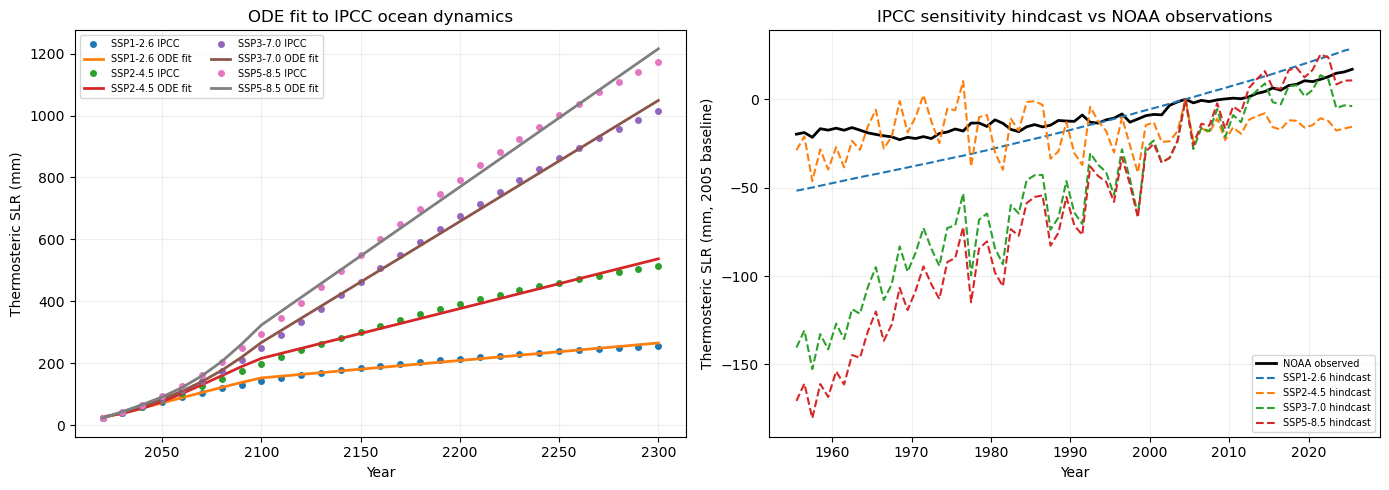

In [4]:
# ── Thermosteric hindcast ──
# Run the IPCC-extracted sensitivity backward through observed GMST

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: IPCC fits (verify)
ax = axes[0]
for ssp, fit in thermo_fits.items():
    comp = ipcc_components[ssp]['oceandynamics']
    ax.plot(comp['years'], comp['median_mm'], 'o', ms=4, label=f'{ssp} IPCC')
    ax.plot(comp['years'], fit['H_fit_m'] * M_TO_MM, '-', lw=2, label=f'{ssp} ODE fit')
ax.set_xlabel('Year')
ax.set_ylabel('Thermosteric SLR (mm)')
ax.set_title('ODE fit to IPCC ocean dynamics')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.2)

# Panel B: Hindcast vs observations
ax = axes[1]
ax.plot(noaa_year, noaa_tsl_rebase * M_TO_MM, 'k-', lw=2, label='NOAA observed')

for ssp, fit in thermo_fits.items():
    # Run ODE through observed T
    S_u_obs, _ = solve_twolayer_ode(temp_monthly, temp_time_monthly, fit['tau_u'], np.inf)
    S_u_annual = np.interp(noaa_year, temp_time_monthly, S_u_obs)
    t_rel = noaa_year - noaa_year[0]
    H_hindcast = fit['a'] * S_u_annual**2 + fit['b'] * S_u_annual + fit['c'] * t_rel + fit['H0']
    # Rebase to 2005
    bl = np.argmin(np.abs(noaa_year - BASELINE_YEAR))
    H_hindcast -= H_hindcast[bl]
    ax.plot(noaa_year, H_hindcast * M_TO_MM, '--', lw=1.5, label=f'{ssp} hindcast')

    # Skill
    valid = np.isfinite(noaa_tsl_rebase)
    resid = noaa_tsl_rebase[valid] - H_hindcast[valid]
    rmse = np.sqrt(np.mean(resid**2)) * M_TO_MM
    r2 = 1 - np.sum(resid**2) / np.sum((noaa_tsl_rebase[valid] - np.mean(noaa_tsl_rebase[valid]))**2)
    print(f'{ssp} hindcast: R²={r2:.4f}, RMSE={rmse:.1f} mm')

ax.set_xlabel('Year')
ax.set_ylabel('Thermosteric SLR (mm, 2005 baseline)')
ax.set_title('IPCC sensitivity hindcast vs NOAA observations')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ipcc_hindcast_thermosteric.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Glaciers

Fit linear and quadratic models to IPCC glacier component for each SSP.
Test whether the IPCC models produce detectably nonlinear sensitivity.

In [5]:
# ── Fit linear + quadratic to IPCC glacier component ──
from numpy.polynomial import polynomial as P

glacier_fits = {}

for ssp in SSP_CODE_MAP:
    if 'glaciers' not in ipcc_components[ssp]:
        continue

    comp = ipcc_components[ssp]['glaciers']
    years_ipcc = comp['years']
    slc_mm = comp['median_mm']

    # Get SSP GMST at IPCC years
    df_ssp = ssp_gmst[ssp]
    T_at_ipcc = np.interp(years_ipcc, df_ssp['decimal_year'].values,
                           df_ssp['temperature'].values)

    # Build design vectors: I1 = cumulative T, I0 = cumulative time
    # For decadal points, use trapezoidal integration
    dt = np.diff(years_ipcc)
    I1 = np.concatenate([[0], np.cumsum(0.5 * (T_at_ipcc[:-1] + T_at_ipcc[1:]) * dt)])
    I2 = np.concatenate([[0], np.cumsum(0.5 * (T_at_ipcc[:-1]**2 + T_at_ipcc[1:]**2) * dt)])
    I0 = years_ipcc - years_ipcc[0]

    slc_m = slc_mm / M_TO_MM

    # Linear fit: H = b*I1 + c*I0 + H0
    X_lin = np.column_stack([I1, I0, np.ones(len(years_ipcc))])
    coeff_lin, res_lin, _, _ = np.linalg.lstsq(X_lin, slc_m, rcond=None)
    H_lin = X_lin @ coeff_lin
    ss_res_lin = np.sum((slc_m - H_lin)**2)
    ss_tot = np.sum((slc_m - np.mean(slc_m))**2)
    r2_lin = 1 - ss_res_lin / ss_tot

    # Quadratic fit: H = a*I2 + b*I1 + c*I0 + H0
    X_quad = np.column_stack([I2, I1, I0, np.ones(len(years_ipcc))])
    coeff_quad, res_quad, _, _ = np.linalg.lstsq(X_quad, slc_m, rcond=None)
    H_quad = X_quad @ coeff_quad
    ss_res_quad = np.sum((slc_m - H_quad)**2)
    r2_quad = 1 - ss_res_quad / ss_tot

    # BIC
    n = len(years_ipcc)
    bic_lin = n * np.log(ss_res_lin / n) + 3 * np.log(n)
    bic_quad = n * np.log(ss_res_quad / n) + 4 * np.log(n)
    delta_bic = bic_lin - bic_quad  # positive = quadratic preferred

    glacier_fits[ssp] = {
        'b_lin': coeff_lin[0], 'c_lin': coeff_lin[1], 'H0_lin': coeff_lin[2],
        'a_quad': coeff_quad[0], 'b_quad': coeff_quad[1], 'c_quad': coeff_quad[2],
        'H0_quad': coeff_quad[3],
        'r2_lin': r2_lin, 'r2_quad': r2_quad, 'delta_bic': delta_bic,
        'H_lin_m': H_lin, 'H_quad_m': H_quad,
        'years': years_ipcc, 'T': T_at_ipcc, 'I1': I1, 'I0': I0,
    }

    print(f'{ssp}: b_lin={coeff_lin[0]*M_TO_MM:.3f} mm/°C, '
          f'a_quad={coeff_quad[0]*M_TO_MM:.4f} mm/°C², '
          f'R²_lin={r2_lin:.6f}, R²_quad={r2_quad:.6f}, '
          f'ΔBIC={delta_bic:+.1f}')

# Cross-SSP comparison
print(f'\nCross-SSP glacier sensitivity:')
bs = [glacier_fits[s]['b_lin']*M_TO_MM for s in glacier_fits]
aqs = [glacier_fits[s]['a_quad']*M_TO_MM for s in glacier_fits]
print(f'  b_lin: {np.mean(bs):.3f} ± {np.std(bs):.3f} mm/yr/°C')
print(f'  a_quad: {np.mean(aqs):.4f} ± {np.std(aqs):.4f} mm/yr/°C²')

SSP1-2.6: b_lin=-0.754 mm/°C, a_quad=7.5692 mm/°C², R²_lin=0.995139, R²_quad=0.996205, ΔBIC=+0.8
SSP2-4.5: b_lin=0.072 mm/°C, a_quad=-0.2001 mm/°C², R²_lin=0.999533, R²_quad=0.999591, ΔBIC=-0.8
SSP3-7.0: b_lin=0.278 mm/°C, a_quad=0.0053 mm/°C², R²_lin=0.997685, R²_quad=0.997685, ΔBIC=-2.6
SSP5-8.5: b_lin=0.261 mm/°C, a_quad=0.0190 mm/°C², R²_lin=0.997976, R²_quad=0.997984, ΔBIC=-2.6

Cross-SSP glacier sensitivity:
  b_lin: -0.036 ± 0.422 mm/yr/°C
  a_quad: 1.8483 ± 3.3041 mm/yr/°C²


SSP1-2.6 glacier hindcast: R²=-1.0245, RMSE=7.4 mm, bias at 2024=-11.6 mm
SSP2-4.5 glacier hindcast: R²=-0.1261, RMSE=5.5 mm, bias at 2024=-9.0 mm
SSP3-7.0 glacier hindcast: R²=-0.2974, RMSE=5.9 mm, bias at 2024=-9.9 mm
SSP5-8.5 glacier hindcast: R²=-1.3707, RMSE=8.0 mm, bias at 2024=-13.8 mm


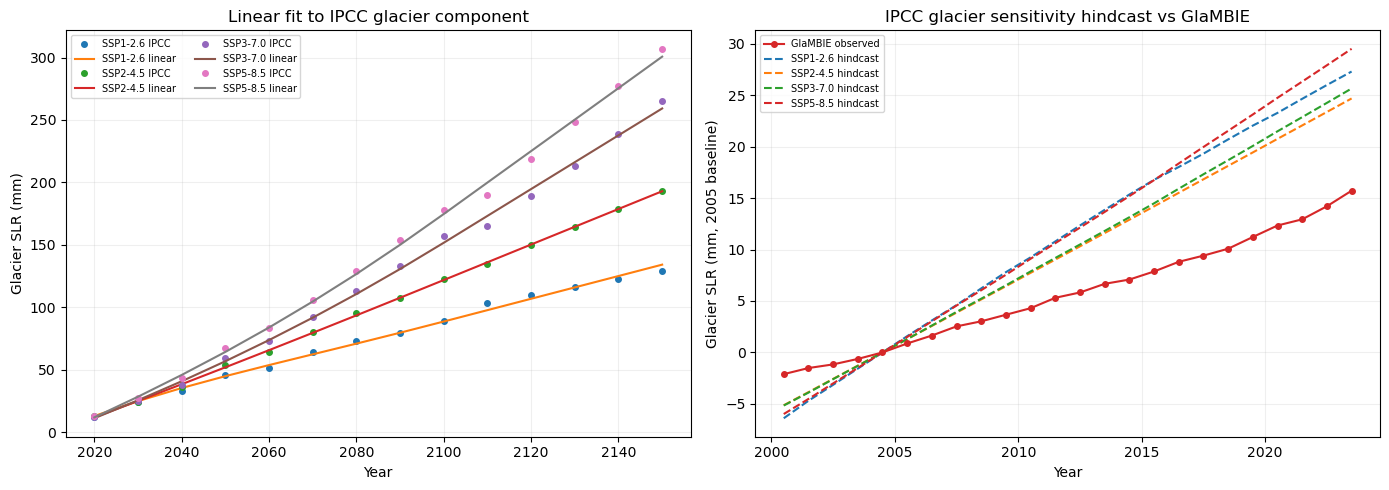

In [6]:
# ── Glacier hindcast ──
# Run IPCC-extracted sensitivity through observed GMST

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: IPCC fits
ax = axes[0]
for ssp, fit in glacier_fits.items():
    comp = ipcc_components[ssp]['glaciers']
    ax.plot(comp['years'], comp['median_mm'], 'o', ms=4, label=f'{ssp} IPCC')
    ax.plot(fit['years'], fit['H_lin_m'] * M_TO_MM, '-', lw=1.5, label=f'{ssp} linear')
ax.set_xlabel('Year')
ax.set_ylabel('Glacier SLR (mm)')
ax.set_title('Linear fit to IPCC glacier component')
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.2)

# Panel B: Hindcast vs GlaMBIE
ax = axes[1]
ax.plot(glac_year, glac_cumul * M_TO_MM, 'C3o-', ms=4, lw=1.5,
        label='GlaMBIE observed', zorder=5)

# Build observed design vectors
dv_obs = build_level_design_vectors(
    temperature_monthly=temp_monthly, time_monthly=temp_time_monthly,
    obs_times=glac_year)
I1_obs = dv_obs['I1_obs']
I0_obs = dv_obs['I0_obs']

for ssp, fit in glacier_fits.items():
    H_hind = fit['b_lin'] * I1_obs + fit['c_lin'] * I0_obs + fit['H0_lin']
    bl = np.argmin(np.abs(glac_year - BASELINE_YEAR))
    H_hind -= H_hind[bl]

    resid = glac_cumul - H_hind
    rmse = np.sqrt(np.mean(resid**2)) * M_TO_MM
    ss_res = np.sum(resid**2)
    ss_tot = np.sum((glac_cumul - np.mean(glac_cumul))**2)
    r2 = 1 - ss_res / ss_tot

    ax.plot(glac_year, H_hind * M_TO_MM, '--', lw=1.5, label=f'{ssp} hindcast')
    print(f'{ssp} glacier hindcast: R²={r2:.4f}, RMSE={rmse:.1f} mm, '
          f'bias at 2024={resid[-1]*M_TO_MM:.1f} mm')

ax.set_xlabel('Year')
ax.set_ylabel('Glacier SLR (mm, 2005 baseline)')
ax.set_title('IPCC glacier sensitivity hindcast vs GlaMBIE')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ipcc_hindcast_glaciers.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Greenland — ISMIP6 SMB/D Decomposition

Load the ISMIP6 Greenland model output (21 models, Goelzer et al. 2020),
decompose into SMB and dynamic contributions, and extract discharge
sensitivities.

ISMIP6 experiments:
- exp05: MIROC5 RCP8.5 (high forcing) — 21 models
- exp07: MIROC5 RCP2.6 (low forcing) — 21 models
- exp08: HadGEM2-ES RCP8.5 (high forcing, different GCM) — 21 models

In [7]:
# ── Load ISMIP6 Greenland model output ──
SEC_PER_YR = 365.25 * 86400

def load_ismip6_greenland(base_dir, exp_name):
    """Load all ISMIP6 models for a given experiment.

    Returns dict of {group/model: {'years': ..., 'sle': ..., 'smb_sle_rate': ...,
    'dyn_rate': ..., 'smb_cumul': ..., 'dyn_cumul': ...}}
    """
    results = {}
    for group in sorted(os.listdir(base_dir)):
        gpath = os.path.join(base_dir, group)
        if not os.path.isdir(gpath): continue
        for model in sorted(os.listdir(gpath)):
            mpath = os.path.join(gpath, model)
            if not os.path.isdir(mpath): continue
            # Find experiment directory
            exp_dir = None
            for d in os.listdir(mpath):
                if d.startswith(exp_name) and os.path.isdir(os.path.join(mpath, d)):
                    exp_dir = os.path.join(mpath, d)
                    break
            if exp_dir is None: continue

            # Find scalars_mm_cr file
            for f in os.listdir(exp_dir):
                if f.startswith('scalars_mm_cr') and f.endswith('.nc'):
                    fpath = os.path.join(exp_dir, f)
                    ds = nc.Dataset(fpath)
                    t = ds.variables['time'][:]
                    sle = ds.variables['sle'][:]
                    smb = ds.variables['smb'][:]
                    oarea = float(ds.variables['oarea'][:])
                    rhow = float(ds.variables['rhow'][:])

                    dates = nc.num2date(t, ds.variables['time'].units,
                                         calendar=ds.variables['time'].calendar)
                    years = np.array([d.year + 0.5 for d in dates])

                    dt = np.diff(years)
                    smb_mid = 0.5 * (smb[:-1] + smb[1:])
                    smb_sle_rate = smb_mid * SEC_PER_YR / (oarea * rhow)
                    dsle_dt = np.diff(sle) / dt
                    dyn_rate = dsle_dt - smb_sle_rate

                    smb_cumul = np.concatenate([[0], np.cumsum(smb_sle_rate * dt)])
                    dyn_cumul = np.concatenate([[0], np.cumsum(dyn_rate * dt)])

                    results[f'{group}/{model}'] = {
                        'years': years,
                        'sle': sle,
                        'smb_sle_rate': smb_sle_rate,
                        'dyn_rate': dyn_rate,
                        'smb_cumul': smb_cumul,
                        'dyn_cumul': dyn_cumul,
                        'yr_mid': 0.5 * (years[:-1] + years[1:]),
                    }
                    ds.close()
                    break
    return results

# Load core experiments
ismip6 = {}
for exp in ['exp05', 'exp07', 'exp08']:
    ismip6[exp] = load_ismip6_greenland(ISMIP6_DIR, exp)
    print(f'{exp}: {len(ismip6[exp])} models loaded')

# Summary table
print(f'\n{"Experiment":<10} {"Total (mm)":<15} {"SMB (mm)":<15} {"Dyn (mm)":<15}')
print('-' * 55)
for exp in ['exp05', 'exp07', 'exp08']:
    totals = [r['sle'][-1]*M_TO_MM for r in ismip6[exp].values()]
    smbs = [r['smb_cumul'][-1]*M_TO_MM for r in ismip6[exp].values()]
    dyns = [r['dyn_cumul'][-1]*M_TO_MM for r in ismip6[exp].values()]
    print(f'{exp:<10} {np.mean(totals):>7.1f}±{np.std(totals):>5.1f}  '
          f'{np.mean(smbs):>7.1f}±{np.std(smbs):>5.1f}  '
          f'{np.mean(dyns):>7.1f}±{np.std(dyns):>5.1f}')

exp05: 21 models loaded
exp07: 21 models loaded
exp08: 21 models loaded

Experiment Total (mm)      SMB (mm)        Dyn (mm)       
-------------------------------------------------------
exp05       -101.4± 19.3    -84.2± 52.4    -17.2± 53.2
exp07        -31.7±  8.3    -52.7± 55.6     20.9± 56.2
exp08        -82.8± 17.8    -62.6± 41.8    -20.2± 44.1


/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_68124/1320528252.py:32: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  smb = ds.variables['smb'][:]
/var/folders/g5/mk_8vz555vs07s6cprrsgg_r0000gn/T/ipykernel_68124/1320528252.py:31: UserWarning: WARNING: missing_value not used since it
cannot be safely cast to variable data type
  sle = ds.variables['sle'][:]


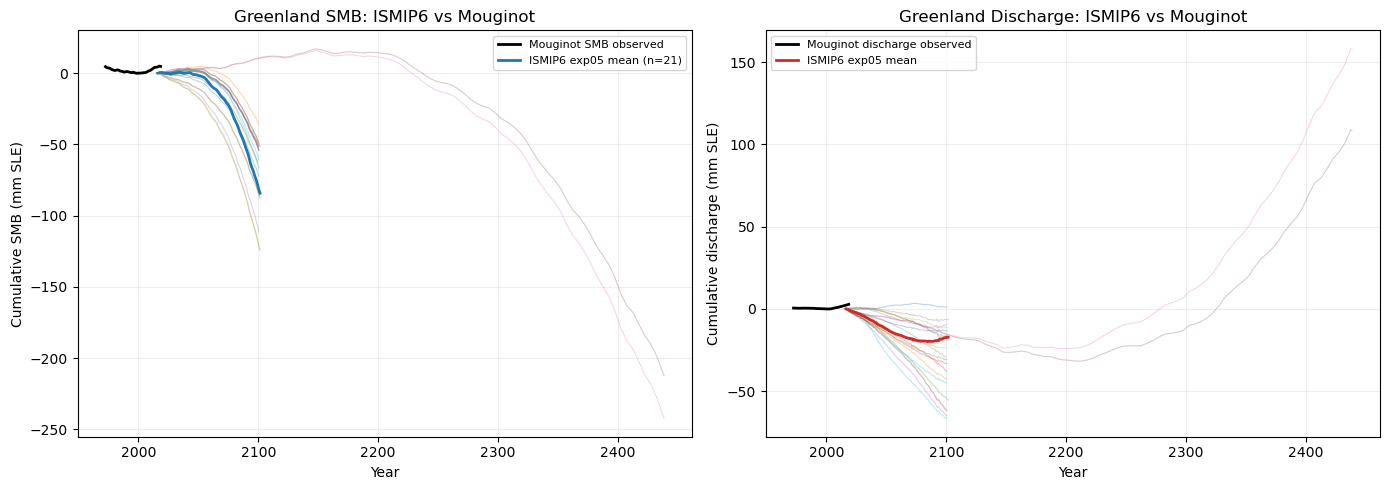

In [8]:
# ── Compare ISMIP6 SMB directly against Mouginot SMB observations ──
# Mouginot provides separate SMB; ISMIP6 provides smb_cumul.
# Both should be in SLE (negative = mass loss = SLR contribution).
# Note: ISMIP6 sle/smb are defined so negative = SLR.

# Load Mouginot SMB component
from bayesian_dols import prepare_mouginot_components
from slr_forecast.readers.ice_sheets import read_mouginot2019_greenland
df_mou_full = read_mouginot2019_greenland(
    f'{RAW_DIR}/ice_sheets/greenland/mouginot2019_data.xlsx')
mou_comp = prepare_mouginot_components(
    df_mou_full, baseline_window=(1995, 2005))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: SMB comparison
ax = axes[0]
ax.plot(mou_comp['time_smb'], mou_comp['H_smb'] * M_TO_MM, 'k-', lw=2,
        label='Mouginot SMB observed')

for name, r in ismip6['exp05'].items():
    ax.plot(r['years'], r['smb_cumul'] * M_TO_MM, '-', alpha=0.3, lw=0.8)
# Ensemble mean
yr_ref = list(ismip6['exp05'].values())[0]['years']
smb_ens = np.array([r['smb_cumul'] for r in ismip6['exp05'].values()])
ax.plot(yr_ref, np.mean(smb_ens, axis=0) * M_TO_MM, 'C0-', lw=2,
        label=f'ISMIP6 exp05 mean (n={len(ismip6["exp05"])})')

ax.set_xlabel('Year')
ax.set_ylabel('Cumulative SMB (mm SLE)')
ax.set_title('Greenland SMB: ISMIP6 vs Mouginot')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

# Panel B: Dynamic comparison
ax = axes[1]
ax.plot(mou_comp['time_dyn'], mou_comp['H_dyn'] * M_TO_MM, 'k-', lw=2,
        label='Mouginot discharge observed')

for name, r in ismip6['exp05'].items():
    ax.plot(r['years'], r['dyn_cumul'] * M_TO_MM, '-', alpha=0.3, lw=0.8)
dyn_ens = np.array([r['dyn_cumul'] for r in ismip6['exp05'].values()])
ax.plot(yr_ref, np.mean(dyn_ens, axis=0) * M_TO_MM, 'C3-', lw=2,
        label=f'ISMIP6 exp05 mean')

ax.set_xlabel('Year')
ax.set_ylabel('Cumulative discharge (mm SLE)')
ax.set_title('Greenland Discharge: ISMIP6 vs Mouginot')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}/ipcc_hindcast_greenland_smb_dyn.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary

Component-by-component comparison of data-driven vs IPCC-implied sensitivities,
with hindcast skill metrics.

In [9]:
# ── Summary table ──
print('='*90)
print('SENSITIVITY COMPARISON: Data-Driven vs IPCC')
print('='*90)
print(f'{"":<15} {"Parameter":<20} {"Data-driven":<20} {"IPCC (SSP2-4.5)":<20} {"Ratio":<10}')
print('-'*90)

# Thermosteric (placeholder for data-driven — fill from component_decomposition results)
if 'SSP2-4.5' in thermo_fits:
    tf = thermo_fits['SSP2-4.5']
    print(f'{"Thermosteric":<15} {"b (mm/yr/°C)":<20} {"[from notebook]":<20} '
          f'{tf["b"]*M_TO_MM:<20.3f} {"—":<10}')
    print(f'{"":<15} {"τ_u (yr)":<20} {"[from notebook]":<20} '
          f'{tf["tau_u"]:<20.1f} {"—":<10}')

# Glaciers
if 'SSP2-4.5' in glacier_fits:
    gf = glacier_fits['SSP2-4.5']
    b_data = 0.77  # from GlaMBIE fit
    b_ipcc = gf['b_lin'] * M_TO_MM
    ratio = b_data / b_ipcc if abs(b_ipcc) > 0.001 else float('nan')
    print(f'{"Glaciers":<15} {"b (mm/yr/°C)":<20} {b_data:<20.3f} '
          f'{b_ipcc:<20.3f} {ratio:<10.2f}')

print('='*90)

# Cross-SSP spread
print(f'\nCross-SSP sensitivity spread:')
print(f'{"Component":<15} {"Parameter":<15} {"Mean":<12} {"Std":<12} {"CV (%)":<10}')
print('-'*65)
for comp_name, fits, key in [
    ('Thermosteric', thermo_fits, 'b'),
    ('Glaciers', glacier_fits, 'b_lin'),
]:
    vals = [f[key]*M_TO_MM for f in fits.values()]
    cv = np.std(vals)/np.mean(vals)*100 if np.mean(vals) != 0 else 0
    print(f'{comp_name:<15} {"b (mm/yr/°C)":<15} {np.mean(vals):<12.3f} '
          f'{np.std(vals):<12.3f} {cv:<10.1f}')

SENSITIVITY COMPARISON: Data-Driven vs IPCC
                Parameter            Data-driven          IPCC (SSP2-4.5)      Ratio     
------------------------------------------------------------------------------------------
Thermosteric    b (mm/yr/°C)         [from notebook]      -76.756              —         
                τ_u (yr)             [from notebook]      0.0                  —         
Glaciers        b (mm/yr/°C)         0.770                0.072                10.75     

Cross-SSP sensitivity spread:
Component       Parameter       Mean         Std          CV (%)    
-----------------------------------------------------------------
Thermosteric    b (mm/yr/°C)    -87.390      12.781       -14.6     
Glaciers        b (mm/yr/°C)    -0.036       0.422        -1175.8   
